# PR04 · Separate smooth intensity bias from tissue contrast

<!-- paper-first -->
### Begin with the paper question

**Read or revisit [PP03](../../curriculum/papers/processing.md#pp03).** Use the assigned first-pass sections in the guide; if you already read them, return only to the relevant figure or claim. Do this before the technical explanation below.

**Motivation:** Why should a segmentation model distinguish smooth scanner-related intensity changes from tissue differences?

Write a two-sentence prediction and one thing you cannot yet explain. Ask your AI tutor to locate evidence in the supplied paper and distinguish it from inference. A paper link motivates this question; it does not mean the paper uses every method demonstrated here.

**After the experiment:** revisit your prediction in the [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md). Explain one mechanism you now understand, cite a result from this notebook, and name a paper claim this exercise still cannot test. Keep a small demonstration distinct from a reproduction of the study.
<!-- /paper-first -->

**Format:** 75–100 minutes for this lesson and its small executable lab, followed by the explicitly labeled upstream practice. Run this notebook from a fresh kernel, top to bottom. Core data are synthetic. Software: NumPy, SciPy, Matplotlib; extra imports are stated in code. This is one stage of a longer processing course, not a replacement for supervised research training.

## Learning objectives

- Distinguish multiplicative bias from additive offset or genuine contrast.
- Test a bias estimate without erasing anatomical differences.
- State what this controlled correction cannot infer from a real scan.

## Understand the operation

An anatomical image can vary in brightness because of tissue composition, acquisition contrast and spatial sensitivity. A smooth multiplicative field is one useful model of the unwanted intensity variation: observed intensity equals underlying intensity times bias. Taking logarithms turns multiplication into addition where the signal is positive. This does not mean every smooth component should be removed. A broad anatomical structure can itself vary slowly.

N4 and FAST use more sophisticated assumptions than dividing by a blurred copy of the image. Masks, resolution, regularization and expected tissue-intensity behavior affect estimation. A bias-corrected image should preserve anatomy while reducing unwanted within-tissue spatial variation. Its intensity scale remains an arbitrary image scale; correction does not turn T1-weighted brightness into a tissue-specific physical measurement.

Here the true synthetic field is known, allowing an oracle correction that isolates the operation. We compare it with a tempting AI shortcut: smooth the observed image and call that the bias field. That shortcut absorbs the two tissue means. Dividing by it makes tissue interiors look alike and may be mistaken for successful uniformity. In research the true field is unavailable, so lower within-region variance is useful only alongside preserved contrast, spatial plausibility and downstream segmentation checks. Dark background and near-zero denominators require an explicit mask; silently filling every division error with zero hides the model's domain.

## Transformation contract

**Input:** positive tissue intensities, a smooth multiplier, and a mask. **Output:** corrected intensities and the estimated field. **Preserved by oracle:** the two tissue levels. **Changed:** unwanted spatial scale modulation. **Risk:** an incorrectly estimated field can remove real contrast.


## Read the actual course material

- [Oxford FSL: Structural Analysis practical](https://pages.fmrib.ox.ac.uk/fslcourse/practicals/seg_struc/index.html). Public university practical; linked only.
- [SimpleITK: N4 Bias Field Correction tutorial](https://simpleitk.readthedocs.io/en/master/link_N4BiasFieldCorrection_docs.html). Official tutorial; linked only.

Read the named topic alongside this lesson; compare its real-image assumptions with our controlled example. These notebooks use original explanations and original code, not copied upstream passages. The source chapter is the place to continue to a complete real-tool practical. External software and downloaded datasets are not silently run by this notebook.


## Predict, then ask your AI assistant

Use Goose with your installed Ollama model, or ChatGPT. The model is a tutor and code author; the local Python runtime performs these calculations. Paste:

> Audit observed=true*bias. Demonstrate the known-field correction and a bad blur/divide estimate. Compare tissue-mean ratio as well as within-tissue variability, and explain why neither alone can validate an unknown real field. Return at most 20 executable lines per cell, show units and array shapes, and preserve the original. Explain the prediction before running. If an assertion fails, diagnose the disagreement rather than deleting the check.

Write your prediction before executing the reference cells below.


In [1]:
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
r,c = np.mgrid[:80,:80]
true = np.where(c<40,60.,100.)
bias = np.exp(.6*(r/79-.5)+.3*(c/79-.5))
observed = true*bias
corrected = observed/bias
bad_field = gaussian_filter(observed,8)
bad = observed/bad_field
left=(c<20)&(r>15)&(r<65); right=(c>60)&(r>15)&(r<65)
contrast = corrected[right].mean()/corrected[left].mean()
bad_contrast = bad[right].mean()/bad[left].mean()
print('correct / shortcut tissue ratios:',contrast,bad_contrast)
assert np.allclose(corrected,true) and np.isclose(contrast,100/60)
assert abs(bad_contrast-1)<.08


correct / shortcut tissue ratios: 1.6666666666666667 1.0132899252763665


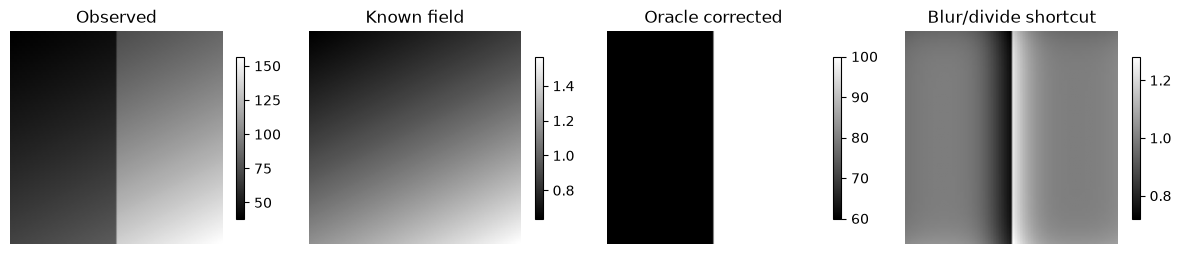

within-tissue CV before/after: 0.10952153283615144 4.475998511201681e-17


In [2]:
fig,axes = plt.subplots(1,4,figsize=(12,3))
for ax,image,title in zip(axes,[observed,bias,corrected,bad],
                         ['Observed','Known field','Oracle corrected','Blur/divide shortcut']):
    shown=ax.imshow(image,cmap='gray'); ax.set_title(title); ax.axis('off')
    fig.colorbar(shown,ax=ax,shrink=.6)
plt.tight_layout(); plt.show()
print('within-tissue CV before/after:',observed[left].std()/observed[left].mean(),
      corrected[left].std()/corrected[left].mean())


## Check and explain

The oracle exactly recovers 60 and 100, keeping their ratio 1.667. The shortcut drives the tissue ratio near one, which exposes lost contrast despite superficially even brightness. The color bars differ because a field, an intensity image and a normalized ratio have different meanings.

## Deliberately wrong method

The shortcut confuses smooth anatomy with smooth bias. Its image is not evidence that bias correction worked. Changing smoothing width to make the result visually attractive does not establish the field model.

## Transfer to an actual dataset or tool — guided assignment

Complete the FAST bias-field/restored-input portion of Oxford Structural Analysis or the official SimpleITK N4 example on its separately obtained image. Save field and restored image, inspect identical cuts with intentional display limits, and compare within-tissue variation and gray/white contrast. Record the mask and all estimation settings. Do not report this synthetic oracle as an implementation or benchmark of N4.

**Submit:** a transformation card, one labeled figure or numerical result, the failed-method diagnosis, and the upstream-practice evidence. If the external exercise has not been run, mark it **not executed** and state the missing software/data; do not convert a proposed command into a claimed result.

## Exit questions and answer key

1. Why does dividing by a smooth image sometimes remove anatomy? **Answer:** the smooth image contains tissue contrast as well as bias.
2. Why retain the estimated field? **Answer:** it exposes the proposed spatial correction and permits checking plausibility and reproducibility.


### Return to the research question

Reopen [PP03](../../curriculum/papers/processing.md#pp03) and your initial two-sentence prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure/section locator. State what this small exercise still cannot establish about the published result.
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Reuse this entry in the A2 portfolio when relevant; a separate report is unnecessary.
